# Gray-Scott Reaction-Diffusion

The Gray-Scott model describes two chemical species $u$ and $v$ that react and diffuse:

$$\frac{\partial u}{\partial t} = D_u\,\nabla^2 u - uv^2 + F(1-u)$$
$$\frac{\partial v}{\partial t} = D_v\,\nabla^2 v + uv^2 - (F+k)v$$

The cubic term $uv^2$ drives an autocatalytic reaction. The parameters $F$ (feed rate) and $k$ (kill rate) control the pattern type: spots, stripes, or spatiotemporal chaos.

We use $F=0.035$, $k=0.065$ which produces stable **spots** (like animal markings). The domain is $[0,1]^2$ with periodic BCs.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
# import sys; sys.path.insert(0, '..')   # adjust path to upde.py and equations.py
# run pip install -e . to install package
from upde import PDE, PDESystem, GrayScott

Solving... (pattern formation requires long integration — expect 2-5 min at 64x64)
Done.


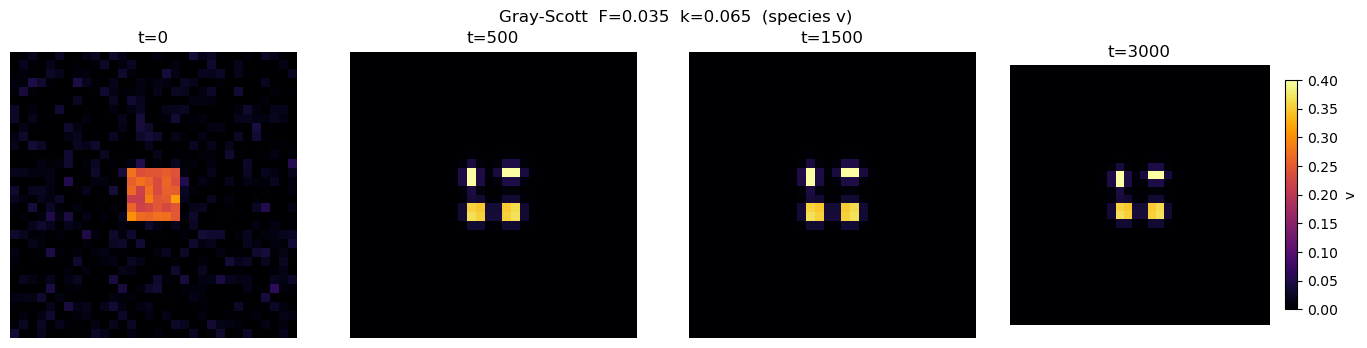

In [2]:
np.random.seed(42)
nx, ny = 32, 32
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)

gs = GrayScott('u', 'v', x=x, y=y,
               Du=2e-5, Dv=1e-5, F=0.035, k=0.065)
gs.u.set_bc(kind='periodic')
gs.v.set_bc(kind='periodic')

# IC: uniform steady state with a seeded perturbation in the centre
u0 = np.ones((nx, ny))
v0 = np.zeros((nx, ny))
cx, cy = nx//2, ny//2;  r = nx//10
u0[cx-r:cx+r, cy-r:cy+r] = 0.5
v0[cx-r:cx+r, cy-r:cy+r] = 0.25
u0 += 0.02 * np.random.randn(nx, ny)
v0 += 0.02 * np.random.randn(nx, ny)
u0 = np.clip(u0, 0, 1);  v0 = np.clip(v0, 0, 1)
gs.u.set_ic(u0);  gs.v.set_ic(v0)

print('Solving... (pattern formation requires long integration — expect 2-5 min at 64x64)')
sol = gs.solve(t_span=(0, 3000), method='BDF',
               t_eval=[0, 500, 1500, 3000],
               rtol=1e-4, atol=1e-6)
print('Done.')

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
fig.suptitle('Gray-Scott  F=0.035  k=0.065  (species v)', fontsize=12)
for ax, k_idx, t in zip(axes, range(4), sol.t):
    im = ax.imshow(sol.v[:,:,k_idx].T, origin='lower', aspect='equal',
                   extent=[0,1,0,1], cmap='inferno', vmin=0, vmax=0.4)
    ax.set_title(f't={t:.0f}')
    ax.axis('off')
plt.colorbar(im, ax=axes[-1], shrink=0.8, label='v')
plt.tight_layout(); plt.show()